## Conditional Workflow

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
BASE_URL = os.getenv('OPENAI_BASE_URL')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' # Set the LangSmith project name

In [3]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    api_key= API_KEY,
    base_url = BASE_URL,
    model = 'gpt-5.1'
)

In [4]:
from typing import List, Dict, Annotated, Optional
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from IPython.display import Image

c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [5]:
class SupportRequest(TypedDict):
    message: str
    priority: int  # 1-> High, 2 -> Med, 3-> Low

In [6]:
def categorize_request(request: SupportRequest):
    # This acts as a routing fucntion
    print(f'Revived Request{request}')

    if "urgent" in request['message'].lower() or request['priority']==1:
        return "high"
    elif "medium" in request['message'].lower() or request['priority']==2:
        return "medium"
    return "low"

def handle_urgent(request: SupportRequest):
    print('Routing to urgent support team')
    request['message'] = "[URGENT]" + 'we will address your issue immediately'
    return request

def handle_medium(request: SupportRequest):
    print(f"Routing to Medium Support Queue:")
    request['message'] = "[MEDIUM] " + "we will address your issue within 24 hours. "
    return request

def handle_standard(request:SupportRequest):
    print(f"Routing to Standard Support Queue: ")
    request['message'] = "[STANDARD] " + "we will address your issue within 72 hours. "
    return request

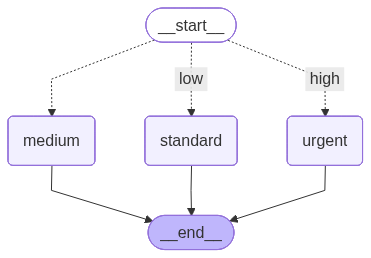

In [7]:
graph = StateGraph(SupportRequest)
graph.add_node('urgent', handle_urgent)
graph.add_node('medium', handle_medium)
graph.add_node('standard', handle_standard)

graph.add_conditional_edges(
    START, 
    categorize_request, 
    {
        'high': 'urgent',
        'medium': 'medium',
        'low': 'standard'
    }
)
graph.add_edge("urgent",END)
graph.add_edge("medium",END)
graph.add_edge("standard",END)

con_flow = graph.compile()
Image(con_flow.get_graph().draw_mermaid_png())

In [8]:
con_flow.invoke({"message": "My account was hacked! Urgent help needed.", "priority": 1})

Revived Request{'message': 'My account was hacked! Urgent help needed.', 'priority': 1}
Routing to urgent support team


{'message': '[URGENT]we will address your issue immediately', 'priority': 1}

In [9]:
con_flow.invoke({"message": "I have a question about my billing cycle.", "priority": 2})

Revived Request{'message': 'I have a question about my billing cycle.', 'priority': 2}
Routing to Medium Support Queue:


{'message': '[MEDIUM] we will address your issue within 24 hours. ',
 'priority': 2}

In [10]:
con_flow.invoke({"message": "I need help updating my profile information.", "priority": 3})

Revived Request{'message': 'I need help updating my profile information.', 'priority': 3}
Routing to Standard Support Queue: 


{'message': '[STANDARD] we will address your issue within 72 hours. ',
 'priority': 3}

### 2nd Flow

In [11]:
from pydantic import BaseModel, Field
from typing import Literal

In [12]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description = 'Sentiment of the review')

class DiagnosisSchema(BaseModel):
    issue_type: Literal['UX', 'Performance', 'Bug', 'Support', 'Other'] = Field(description = 'The category of issue mentioned in the review')
    tone: Literal['angry', 'fustrated', 'disappointed', 'calm'] = Field(description = 'The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


sentiment_model = model.with_structured_output(SentimentSchema)
diagnosis_model = model.with_structured_output(DiagnosisSchema)

In [13]:
prompt = 'What is the sentiment of the following review - The software too good'
sentiment_model.invoke(prompt)

SentimentSchema(sentiment='positive')

In [14]:
prompt = 'Analyze the following user review and provide a diagnosis - The app crashes every time I try to upload a photo, and it makes me so frustrated!'
diagnosis_model.invoke(prompt)

DiagnosisSchema(issue_type='Bug', tone='fustrated', urgency='high')

In [15]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [20]:
def find_sentiment(state: ReviewState):
    prompt = f'For the following review find out the sentiment\n\n{state['review']}'
    sentiment = sentiment_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n
    Return issue_type, tone, and urgency.
    """
    response = diagnosis_model.invoke(prompt)
    return {'diagnosis': response.model_dump()}

def negative_sentiment(state: ReviewState):
    diagnosis= state['diagnosis']
    prompt = f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response = model.invoke(prompt).content
    return {'response': response}

def positive_response(state: ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).content
    return {'response': response}

In [23]:
graph = StateGraph(ReviewState)
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_sentiment', negative_sentiment)

# Adding teh edges
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges(
    'find_sentiment',
    check_sentiment,
    {
        'positive_response': 'positive_response', 
        'run_diagnosis': 'run_diagnosis'
    }
)

graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_sentiment')
graph.add_edge('negative_sentiment', END)

workflow = graph.compile()

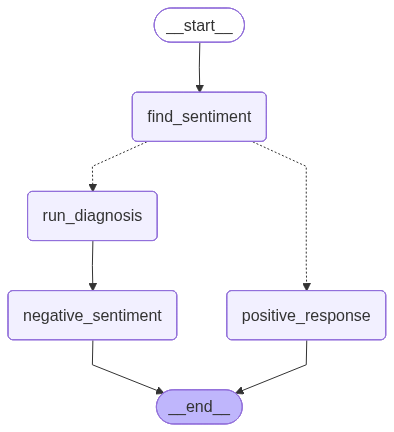

In [24]:
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

response = workflow.invoke(intial_state)
print(response)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'Bug', 'tone': 'fustrated', 'urgency': 'high'}, 'response': 'I’m really sorry you’ve run into this—especially when it’s urgent. I know how frustrating it is when something that should “just work” blocks you.\n\nHere’s what we’ll do to move things forward quickly:\n\n1. **What we understand so far**  \n   You’ve reported a bug and marked the urgency as high, so we’re treating this as a priority. Our goal is to get you unblocked as fast as possible while also fixing the root cause.\n\n2. **Immediate next steps**  \n   To diagnose and resolve this, please share (if you haven’t already):\n   - A brief description of what you were trying to do  \n   - The exact error message or behavior you’re seei

In [29]:
from pprint import pprint
pprint(response)

{'diagnosis': {'issue_type': 'Bug', 'tone': 'fustrated', 'urgency': 'high'},
 'response': 'I’m really sorry you’ve run into this—especially when it’s '
             'urgent. I know how frustrating it is when something that should '
             '“just work” blocks you.\n'
             '\n'
             'Here’s what we’ll do to move things forward quickly:\n'
             '\n'
             '1. **What we understand so far**  \n'
             '   You’ve reported a bug and marked the urgency as high, so '
             'we’re treating this as a priority. Our goal is to get you '
             'unblocked as fast as possible while also fixing the root cause.\n'
             '\n'
             '2. **Immediate next steps**  \n'
             '   To diagnose and resolve this, please share (if you haven’t '
             'already):\n'
             '   - A brief description of what you were trying to do  \n'
             '   - The exact error message or behavior you’re seeing  \n'
             '   - A

In [30]:
intial_state={
    'review': "The product is awesome, I love the built quality"
}

response = workflow.invoke(intial_state)
pprint(response)

{'response': 'Thank you so much for your wonderful review! It makes us really '
             'happy to hear that you’re loving the product and its build '
             'quality.  \n'
             '\n'
             'If you have a moment, we’d be grateful if you could also share '
             'your feedback on our website—your review helps other customers '
             'and supports us in continuing to improve.',
 'review': 'The product is awesome, I love the built quality',
 'sentiment': 'positive'}
